In [58]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns


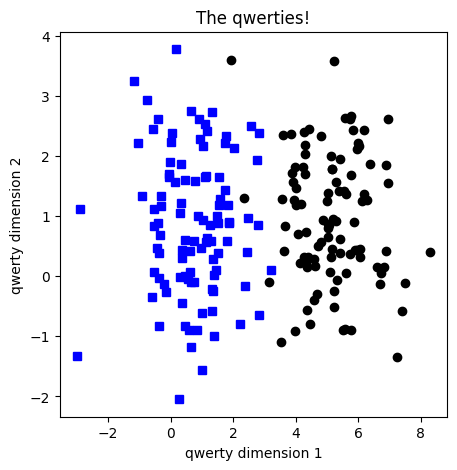

In [59]:
# create data

nPerClust = 100
blur = 1.2

A = [  1, 1 ]
B = [  5, 1 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]

# true labels
labels_np = np.vstack((np.zeros((nPerClust,1)),np.ones((nPerClust,1))))

# concatanate into a matrix
data_np = np.hstack((a,b)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [63]:
#create the model 
model=nn.Sequential(
    nn.Linear(2 , 10),
    nn.ReLU(),
    nn.Linear(10 ,1),
    nn.Sigmoid()
    )


In [81]:
# lerning rate and solver 
lr=np.linspace(0.001 , 0.05 , 10)
lossfun=nn.BCELoss()
losses=[[] for learningrate in lr]

for j , learningrate in enumerate(lr):
   solver=torch.optim.Adam(model.parameters() , lr=learningrate)
   epochs=10000 
   for i in range(epochs):
       #forward prop 
       y_preds=model(data)
       
       #error
       loss=lossfun(y_preds , labels)
       losses[j].append(loss.item())
       
       #backprop
       solver.zero_grad() #this is important to prevent accumulation of gradients
       loss.backward()
       solver.step() #this is where the weights are updated
       
       

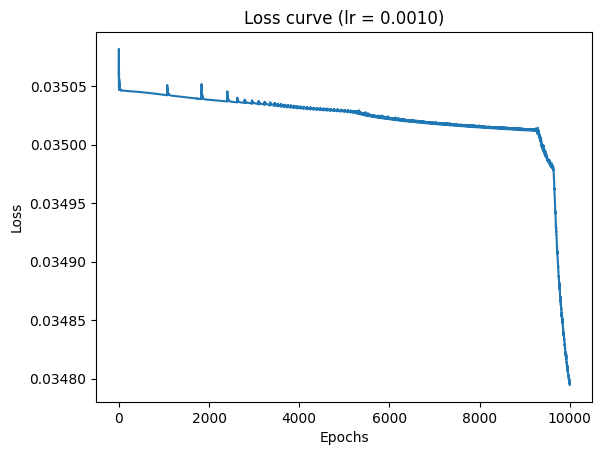

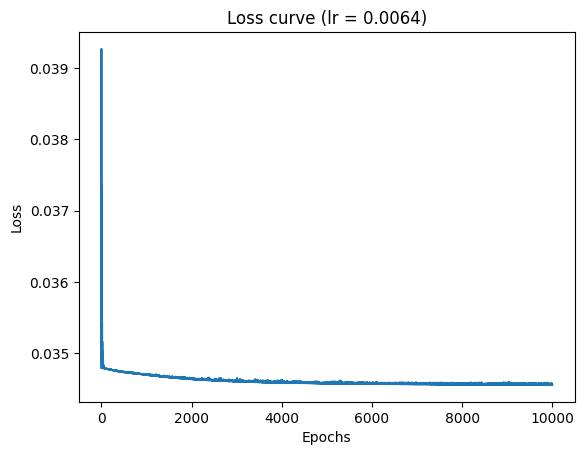

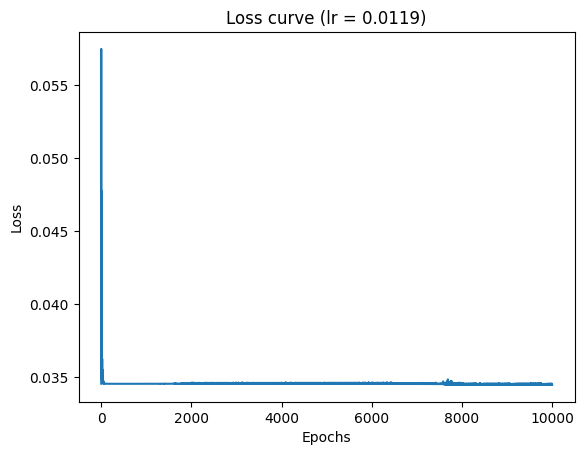

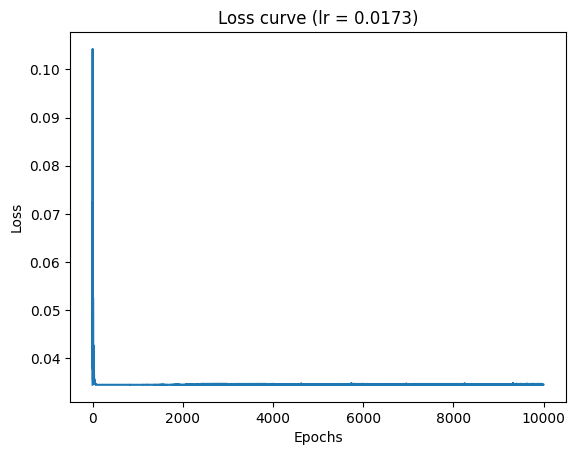

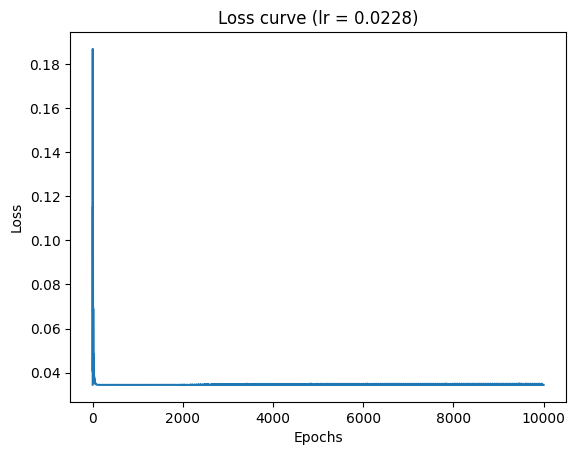

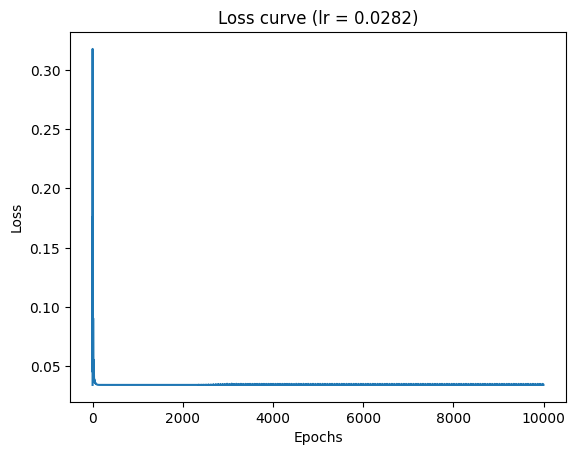

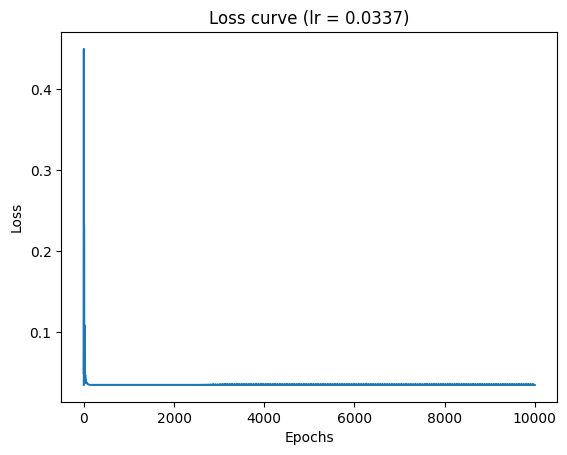

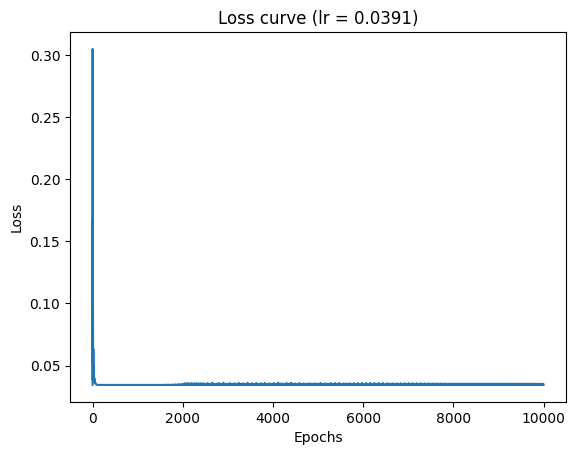

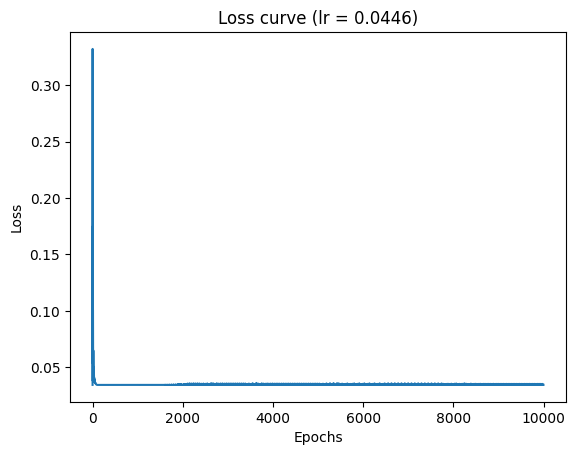

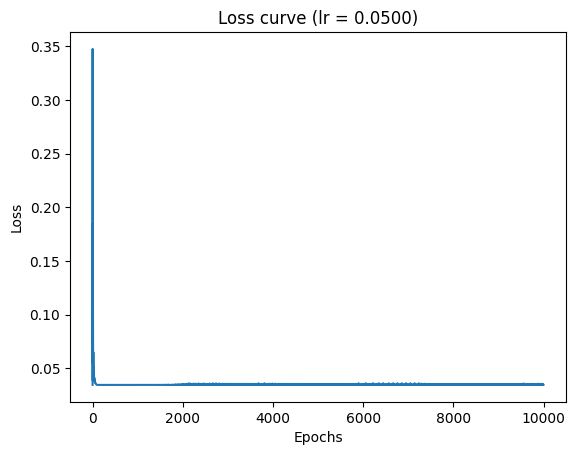

In [82]:
for lr_i, learningrate in enumerate(lr):

    plt.figure()  # create a new graph
    sns.lineplot(
        x=range(len(losses[lr_i])),
        y=losses[lr_i]
    )

    plt.title(f"Loss curve (lr = {learningrate:.4f})")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")

    plt.show()